In [1]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.ticker import MaxNLocator

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (
        candidate
        for candidate in (CURRENT_DIR, *CURRENT_DIR.parents)
        if (candidate / "modules").is_dir() and (candidate / "pipelines").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root from the current working directory")

SCENARIO_DIR = CURRENT_DIR
if not (SCENARIO_DIR / "contact_plan_2.json").exists():
    scenario_candidate = REPO_ROOT / "scenarios" / "wisee_four_planes_polar"
    if not scenario_candidate.exists():
        raise RuntimeError("Could not locate the scenario directory wisee_four_planes_polar")
    SCENARIO_DIR = scenario_candidate

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from models.model1_max_routes import (
    plot_selected_routes_vs_keys,
    solve_for_security_model as solve_m1_for_security_model,
)
from models.model2_min_keys import (
    plot_connectivity_pair_coverage_heatmap,
    plot_selected_keys_vs_connectivity,
    solve_for_security_model as solve_m2_for_security_model,
)
from models.model3_min_keys_full_connectivity import (
    plot_selected_keys_by_model,
    plot_selected_routes_by_model,
    solve_for_security_model as solve_m3_for_security_model,
)
from models.model4_max_connectivity_under_budget import (
    plot_budget_pair_coverage_heatmap,
    plot_connectivity_vs_budget,
    solve_for_security_model as solve_m4_for_security_model,
)
from modules.network.temporal_graph import plot_temporal_graph
from models.plot_utils import (
    MODEL_DISPLAY_ORDER,
    MODEL_PALETTE,
    auxiliary_cmap,
    format_model_label,
    format_model_series,
    palette_for,
    plot_metric_bars_by_model,
    secondary_palette,
    set_plot_theme,
)
from modules.security.models import KeyType, SecurityModelType
from pipelines.route_activation import RouteActivationPlanner
from pipelines.routing import CGRYenRouting
from pipelines.simulation import SimulationPipeline

set_plot_theme()
set_matplotlib_formats("svg")

PAPER_FIG_DIR = REPO_ROOT / "WISEE_2026_DTN_Security_Schemes_Optimization" / "5_analysis"
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_paper_figure(fig, stem: str) -> None:
    fig.savefig(PAPER_FIG_DIR / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(PAPER_FIG_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# Four planes polar scenario

/Users/ramirodetke/.pyenv/versions/bpsec-keys/lib/python3.13/site-packages/teneto/neuroimagingtools/fmriutils.py:6: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiLabelsMasker


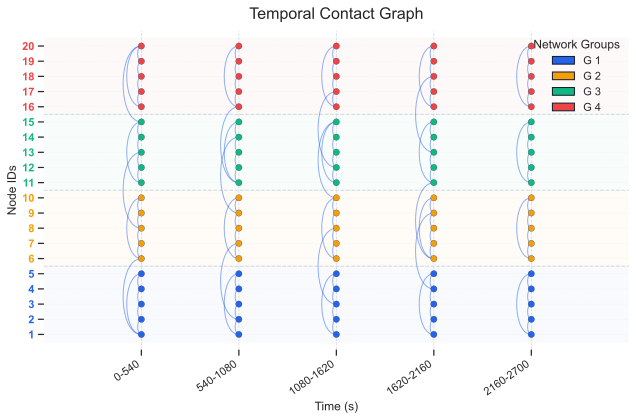

In [2]:
set_plot_theme()

contact_plan = json.loads((SCENARIO_DIR / "contact_plan_2.json").read_text())
topology = json.loads((SCENARIO_DIR / "topology.json").read_text())

fig, ax = plot_temporal_graph(
    contact_plan=contact_plan,
    topology=topology,
    title="Temporal Contact Graph",
    network_label_prefix="G",
    figsize=(9,6),
    nodesize=40,
)
plt.show()


In [3]:
max_routes = 3
pipeline = SimulationPipeline()

result = pipeline.run(
    cp_path=str(SCENARIO_DIR / "contact_plan_2.json"),
    topology_path=str(SCENARIO_DIR / "topology.json"),
    security_models=tuple(SecurityModelType),
    curr_time=0,
    routing_algorithm=CGRYenRouting(max_routes=max_routes),
)


In [4]:
set_plot_theme()

SERIES_COLORS = {
    model: MODEL_PALETTE[format_model_label(model)]
    for model in SecurityModelType
}
KEY_TYPE_ORDER = ["N-N", "N-G", "G-G", "Total"]
KEY_TYPE_PALETTE = secondary_palette(KEY_TYPE_ORDER)
ROUTE_HEATMAP_CMAP = auxiliary_cmap("routes")


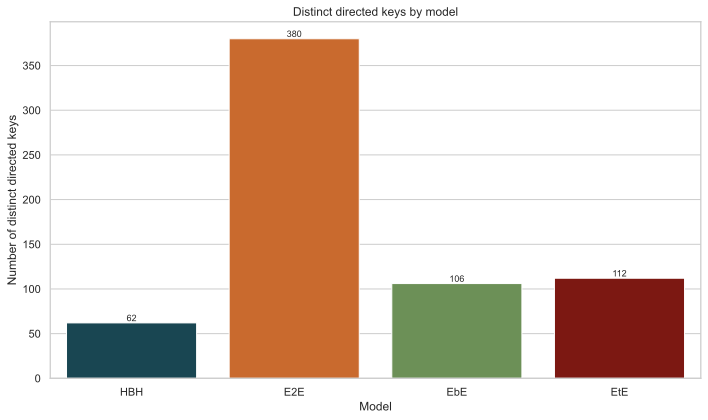

In [5]:
planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    rows.append(
        {
            "model": model,
            "unique_keys": len(planning.key_scopes),
        }
    )

df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 6))
plot_metric_bars_by_model(
    df,
    y="unique_keys",
    ax=ax,
    y_label="Number of distinct directed keys",
    title="Distinct directed keys by model",
)

plt.tight_layout()
plt.show()


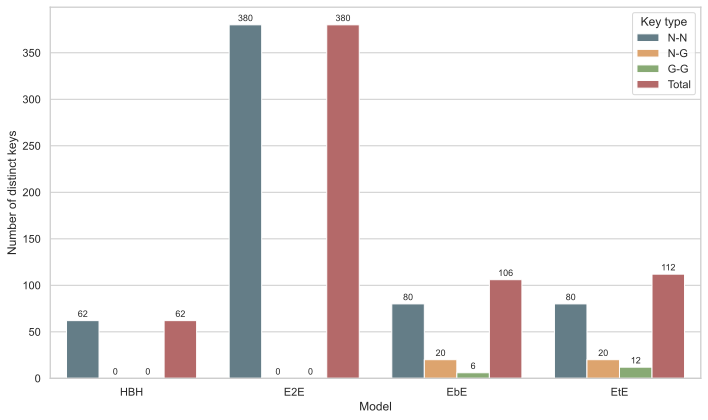

In [6]:
planner = RouteActivationPlanner()

rows = []
for model in SecurityModelType:
    planning = planner.build_for_model(result.security, model=model)
    key_scopes = planning.key_scopes

    counts = {
        "N-N": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_NODE),
        "N-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.NODE_TO_GROUP),
        "G-G": sum(1 for scope in key_scopes if scope.key_type == KeyType.GROUP_TO_GROUP),
    }
    counts["Total"] = len(key_scopes)

    for key_type_label in KEY_TYPE_ORDER:
        rows.append(
            {
                "model": model,
                "key_type": key_type_label,
                "count": counts[key_type_label],
            }
        )

df = pd.DataFrame(rows)
df["model"] = format_model_series(df["model"])

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x="model",
    y="count",
    hue="key_type",
    order=MODEL_DISPLAY_ORDER,
    hue_order=KEY_TYPE_ORDER,
    palette=KEY_TYPE_PALETTE,
)

ax.set_ylabel("Number of distinct keys")
ax.set_xlabel("Model")
ax.legend(title="Key type")

for container in ax.containers:
    ax.bar_label(container, padding=2, fontsize=9)

plt.tight_layout()
plt.show()


In [7]:
def unique_scopes_by_model(sim_result, model_type):
    return {
        req.scope
        for pair in sim_result.security.pairs
        for plan in sim_result.security.plans_by_model[model_type][pair]
        for req in plan.key_requirements
    }


def format_scope(scope):
    return f"G{scope.source_id}->G{scope.target_id}"


ebe_label = format_model_label(SecurityModelType.EDGE_BY_EDGE)
ete_label = format_model_label(SecurityModelType.EDGE_TO_EDGE)

ebe_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_BY_EDGE)
ete_scopes = unique_scopes_by_model(result, SecurityModelType.EDGE_TO_EDGE)

ebe_gg = {
    scope for scope in ebe_scopes if scope.key_type == KeyType.GROUP_TO_GROUP
}
ete_gg = {
    scope for scope in ete_scopes if scope.key_type == KeyType.GROUP_TO_GROUP
}

summary_df = pd.DataFrame(
    [
        {"Model": ebe_label, "Unique G-G": len(ebe_gg)},
        {"Model": ete_label, "Unique G-G": len(ete_gg)},
    ]
)

all_gg = sorted(
    ebe_gg | ete_gg,
    key=lambda scope: (scope.source_id, scope.target_id),
)

comparison_df = pd.DataFrame(
    {
        "Scope": [format_scope(scope) for scope in all_gg],
        ebe_label: [format_scope(scope) if scope in ebe_gg else "" for scope in all_gg],
        ete_label: [format_scope(scope) if scope in ete_gg else "" for scope in all_gg],
    }
)

display(summary_df)
display(comparison_df)


,Model,Unique G-G
0,EbE,6
1,EtE,12


,Scope,EbE,EtE
0,G1->G2,G1->G2,G1->G2
1,G1->G3,,G1->G3
2,G1->G4,,G1->G4
3,G2->G1,G2->G1,G2->G1
4,G2->G3,G2->G3,G2->G3
5,G2->G4,,G2->G4
6,G3->G1,,G3->G1
7,G3->G2,G3->G2,G3->G2
8,G3->G4,G3->G4,G3->G4
9,G4->G1,,G4->G1


## Edge by Edge Group to Group unique key scopes
```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

```
## Edge by Edge Group to Group unique key scopes
* Dashed line arrows represent distinct key scopes used by edge-to-edge
* Continous line arrows represent shared key scopes between edge-to-edge and edge-by-edge
```mermaid
graph LR
    G1["G1"]
    G2["G2"]
    G3["G3"]
    G4["G4"]

    G1 --> G2
    G2 --> G1
    G2 --> G3
    G3 --> G2
    G3 --> G4
    G4 --> G3

    G1 -.-> G3
    G1 -.-> G4
    G2 -.-> G4
    G3 -.-> G1
    G4 -.-> G1
    G4 -.-> G2

```

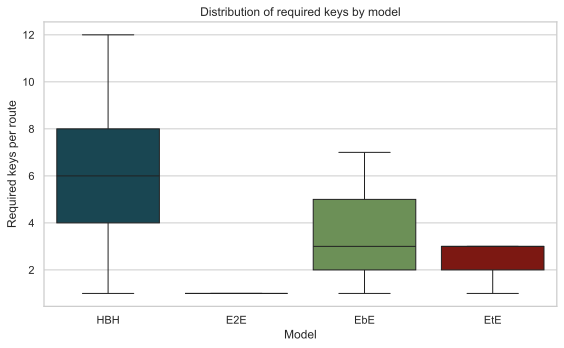

In [8]:
rows = []

for model, plans_by_pair in result.security.plans_by_model.items():
    for pair, plans in plans_by_pair.items():
        for plan in plans:
            unique_scopes = {req.scope for req in plan.key_requirements}
            rows.append(
                {
                    "model": format_model_label(model),
                    "pair": f"{pair[0]}->{pair[1]}",
                    "route": f"{pair[0]}->{pair[1]}:{plan.route_id}",
                    "required_keys": len(unique_scopes),
                }
            )

df_keys = pd.DataFrame(rows)
df_keys["model"] = format_model_series(df_keys["model"])

plt.figure(figsize=(8, 5))
ax = sns.boxplot(
    data=df_keys,
    x="model",
    y="required_keys",
    hue="model",
    order=MODEL_DISPLAY_ORDER,
    hue_order=MODEL_DISPLAY_ORDER,
    dodge=False,
    palette=palette_for(df_keys["model"]),
    legend=False,
)
ax.set_title("Distribution of required keys by model")
ax.set_xlabel("Model")
ax.set_ylabel("Required keys per route")

plt.tight_layout()
plt.show()


## Model 1 - Maximize routes subject to a key budget

<table>
<tr>
<td style="width:50%; border:none; vertical-align:top;">

#### Notation
$$
\begin{aligned}
D &: \text{set of evaluated ordered source-destination pairs} \\
P_{sd} &: \text{set of candidate routes for pair } (s,d) \in D \\
P &= \bigcup_{(s,d) \in D} P_{sd} \\
K &: \text{global set of activatable key scopes} \\
K(p) &\subseteq K : \text{key scopes required by route } p \in P \\
B &: \text{maximum budget of active keys}
\end{aligned}
$$

$$
\begin{aligned}
y_p &=
\begin{cases}
1 & \text{if route } p \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
z_k &=
\begin{cases}
1 & \text{if key scope } k \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\end{aligned}
$$

</td>
<td style="width:50%; border:none; vertical-align:top;">

#### Model
$$
\begin{aligned}
\max \quad & \sum_{p \in P} y_p \\
\text{s.t.} \quad
& \sum_{k \in K} z_k \le B \\
& \sum_{k \in K(p)} z_k \ge |K(p)|\,y_p \qquad \forall p \in P \\
& y_p \in \{0,1\} \qquad \forall p \in P \\
& z_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
$$

</td>
</tr>
</table>


In [9]:
df_m1 = pd.DataFrame()
traces_m1 = {}
for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")

    sec_traces, sec_df = solve_m1_for_security_model(result, sec_model)
    traces_m1[sec_model.name] = dict(zip(sec_df["max_keys"], sec_traces))
    df_m1 = pd.concat([df_m1, sec_df])


Running for HOP_BY_HOP
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2821306
Academic license 2821306 - for non-commercial use only - registered to ra___@unc.edu.ar
Running for END_TO_END
Running for EDGE_BY_EDGE
Running for EDGE_TO_EDGE


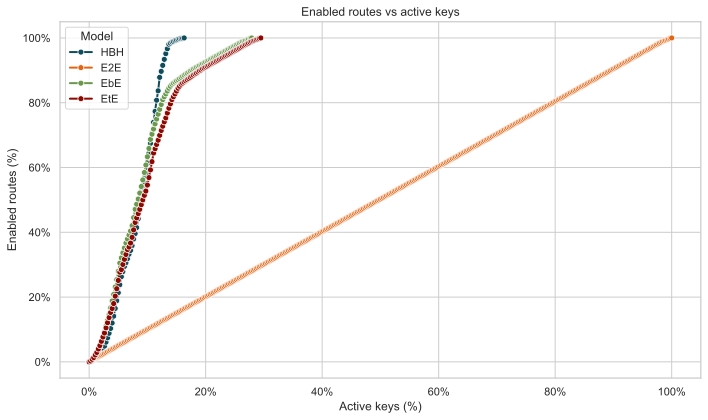

In [10]:
ax = plot_selected_routes_vs_keys(
    df_m1,
    normalize=True,
    title="Enabled routes vs active keys",
)
ax.figure.tight_layout()
plt.show()


## Model 2 **(WiSEE)**- Minimize keys for a pair-connectivity target 

<table>
<tr>
<td style="width:50%; border:none; vertical-align:top;">

#### Notation
$$
\begin{aligned}
D &: \text{set of evaluated ordered source-destination pairs} \\
P_{sd} &: \text{set of candidate routes for pair } (s,d) \in D \\
P &= \bigcup_{(s,d) \in D} P_{sd} \\
K &: \text{global set of activatable key scopes} \\
K(p) &\subseteq K : \text{key scopes required by route } p \in P \\
\gamma &: \text{target connectivity fraction}
\end{aligned}
$$

$$
\begin{aligned}
x_{sd} &=
\begin{cases}
1 & \text{if pair } (s,d) \text{ is connected} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
y_p &=
\begin{cases}
1 & \text{if route } p \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
z_k &=
\begin{cases}
1 & \text{if key scope } k \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\end{aligned}
$$

</td>
<td style="width:50%; border:none; vertical-align:top;">

#### Model
$$
\begin{aligned}
\min \quad & \sum_{k \in K} z_k \\
\text{s.t.} \quad
& \sum_{(s,d) \in D} x_{sd} \ge \left\lceil \gamma |D| \right\rceil \\
& y_p \le x_{sd} \qquad \forall (s,d) \in D,\ \forall p \in P_{sd} \\
& x_{sd} \le \sum_{p \in P_{sd}} y_p \qquad \forall (s,d) \in D \\
& \sum_{k \in K(p)} z_k \ge |K(p)|\,y_p \qquad \forall p \in P \\
& x_{sd} \in \{0,1\} \qquad \forall (s,d) \in D \\
& y_p \in \{0,1\} \qquad \forall p \in P \\
& z_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
$$

</td>
</tr>
</table>


In [19]:
df_m2 = pd.DataFrame()
traces_m2 = {}

for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")

    sec_traces, sec_df = solve_m2_for_security_model(result, sec_model)
    traces_m2[sec_model.name] = dict(zip(sec_df["target_connectivity_pct"], sec_traces))
    df_m2 = pd.concat([df_m2, sec_df], ignore_index=True)


Running for HOP_BY_HOP
Running for END_TO_END
Running for EDGE_BY_EDGE
Running for EDGE_TO_EDGE


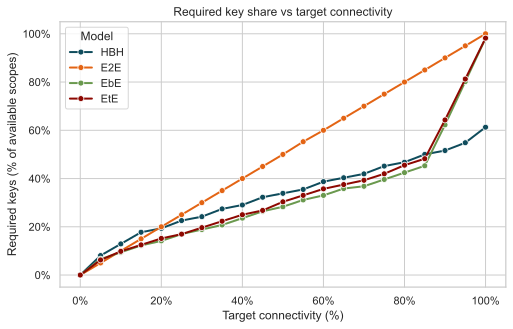

In [55]:
# WiSEE plot
from models.plot_utils import plot_metric_curve

planner = RouteActivationPlanner()
total_scopes_by_model = {
    model.name: len(planner.build_for_model(result.security, model=model).key_scopes)
    for model in SecurityModelType
}

df_m2_paper = df_m2.copy()
df_m2_paper["total_key_scopes"] = df_m2_paper["model"].map(total_scopes_by_model)
df_m2_paper["selected_keys_pct_of_available"] = (
    100.0 * df_m2_paper["selected_keys"] / df_m2_paper["total_key_scopes"]
)
df_m2_paper["model"] = format_model_series(df_m2_paper["model"])

set_plot_theme()
fig, ax = plt.subplots(figsize=(8, 4.8))

plot_metric_curve(
    df_m2_paper,
    x="target_connectivity_pct",
    y="selected_keys_pct_of_available",
    ax=ax,
    sort_by="target_connectivity_pct",
    palette=palette_for(df_m2_paper["model"]),
    x_percent_scale=100,
    y_percent_scale=100,
    x_label="Target connectivity (%)",
    y_label="Required keys (% of available scopes)",
    title="Required key share vs target connectivity",
)

save_paper_figure(fig, "model2_fpp_required_key_share_vs_connectivity")


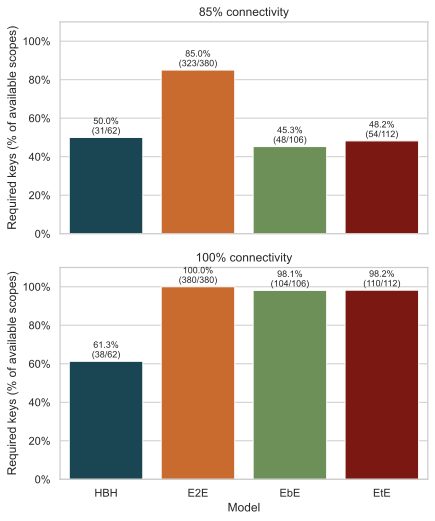

In [59]:
# WiSEE plot
model2_focus_targets = [85, 100]

fig, axes = plt.subplots(2, 1, figsize=(6.2, 7.4), sharex=True, sharey=True)

for ax, target in zip(axes, model2_focus_targets, strict=True):
    target_df = df_m2_paper[df_m2_paper["target_connectivity_pct"] == target].copy()
    plot_metric_bars_by_model(
        target_df.rename(columns={"selected_keys_pct_of_available": "required_keys_pct"}),
        y="required_keys_pct",
        ax=ax,
        palette=palette_for(target_df["model"]),
        y_percent_scale=100,
        y_label="Required keys (% of available scopes)",
        title=f"{target}% connectivity",
    )

    for text in list(ax.texts):
        text.remove()

    for bar, row in zip(ax.patches, target_df.itertuples(index=False), strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1.0,
            f"{row.selected_keys_pct_of_available:.1f}%\n({int(row.selected_keys)}/{int(row.total_key_scopes)})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_ylim(0, 110)

# fig.suptitle("Required key share by model at selected connectivity targets", y=1.02)
fig.tight_layout()
save_paper_figure(fig, "model2_fpp_required_key_share_targets")


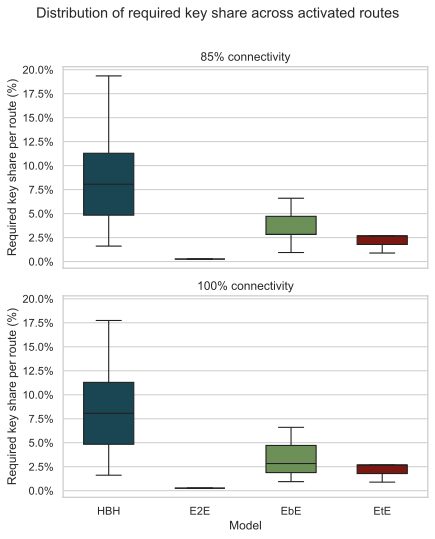

In [61]:
# WiSEE plot
if "model2_focus_targets" not in globals():
    model2_focus_targets = [85, 100]

if "total_scopes_by_model" not in globals():
    planner = RouteActivationPlanner()
    total_scopes_by_model = {
        model.name: len(planner.build_for_model(result.security, model=model).key_scopes)
        for model in SecurityModelType
    }

rows = []
for model_name, traces_by_target in traces_m2.items():
    for target in model2_focus_targets:
        trace = traces_by_target.get(target)
        if trace is None:
            continue

        total_key_scopes = total_scopes_by_model[model_name]

        for route in trace.routes:
            required_keys = len(route.required_key_scopes)
            rows.append(
                {
                    "model": model_name,
                    "target_connectivity_pct": target,
                    "pair": route.pair_id,
                    "route_id": route.route_id,
                    "required_keys_per_route": required_keys,
                    "required_keys_pct_per_route": 100.0 * required_keys / total_key_scopes,
                    "security_operations_per_route": len(route.operations),
                }
            )

model2_route_distribution_df = pd.DataFrame(rows)
model2_route_distribution_df["model"] = format_model_series(model2_route_distribution_df["model"])

fig, axes = plt.subplots(2, 1, figsize=(6.2, 7.4), sharex=True, sharey=True)

for ax, target in zip(axes, model2_focus_targets, strict=True):
    target_df = model2_route_distribution_df[
        model2_route_distribution_df["target_connectivity_pct"] == target
    ].copy()

    sns.boxplot(
        data=target_df,
        x="model",
        y="required_keys_pct_per_route",
        order=MODEL_DISPLAY_ORDER,
        hue="model",
        hue_order=MODEL_DISPLAY_ORDER,
        palette=MODEL_PALETTE,
        dodge=False,
        legend=False,
        width=0.55,
        fliersize=2.5,
        linewidth=1.1,
        ax=ax,
    )

    ax.set_title(f"{target}% connectivity")
    ax.set_xlabel("Model")
    ax.set_ylabel("Required key share per route (%)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(100))

fig.suptitle("Distribution of required key share across activated routes", y=1.01)
fig.tight_layout()
save_paper_figure(fig, "model2_fpp_required_key_share_distribution_targets")


## Model 3 - Minimize keys while guaranteeing at least 1 path per pair

<table>
<tr>
<td style="width:50%; border:none; vertical-align:top;">

#### Notation
$$
\begin{aligned}
D &: \text{set of evaluated ordered source-destination pairs} \\
P_{sd} &: \text{set of candidate routes for pair } (s,d) \in D \\
P &= \bigcup_{(s,d) \in D} P_{sd} \\
K &: \text{global set of activatable key scopes} \\
K(p) &\subseteq K : \text{key scopes required by route } p \in P
\end{aligned}
$$

$$
\begin{aligned}
x_{sd} &=
\begin{cases}
1 & \text{if pair } (s,d) \text{ is connected} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
y_p &=
\begin{cases}
1 & \text{if route } p \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
z_k &=
\begin{cases}
1 & \text{if key scope } k \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\end{aligned}
$$

</td>
<td style="width:50%; border:none; vertical-align:top;">

#### Model
$$
\begin{aligned}
\min \quad & \sum_{k \in K} z_k \\
\text{s.t.} \quad
& x_{sd} = 1 \qquad \forall (s,d) \in D \\
& y_p \le x_{sd} \qquad \forall (s,d) \in D,\ \forall p \in P_{sd} \\
& x_{sd} \le \sum_{p \in P_{sd}} y_p \qquad \forall (s,d) \in D \\
& \sum_{k \in K(p)} z_k \ge |K(p)|\,y_p \qquad \forall p \in P \\
& x_{sd} \in \{0,1\} \qquad \forall (s,d) \in D \\
& y_p \in \{0,1\} \qquad \forall p \in P \\
& z_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
$$

</td>
</tr>
</table>


In [13]:
df_m3 = pd.DataFrame()
traces_m3 = {}

for sec_model in SERIES_COLORS.keys():
    sec_traces, sec_df = solve_m3_for_security_model(result, sec_model)
    traces_m3[sec_model.name] = sec_traces[0] if sec_traces else None
    df_m3 = pd.concat([df_m3, sec_df], ignore_index=True)


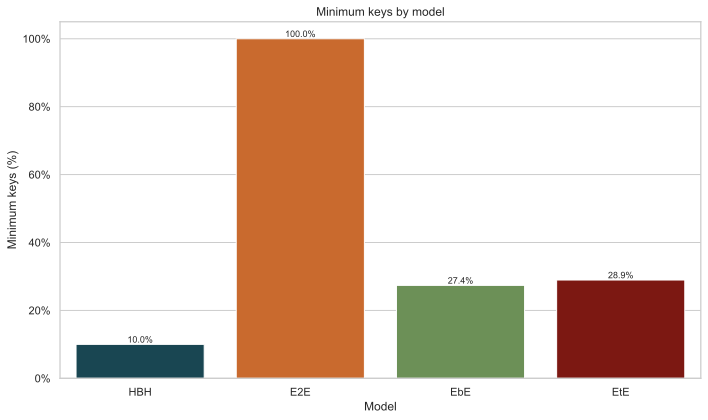

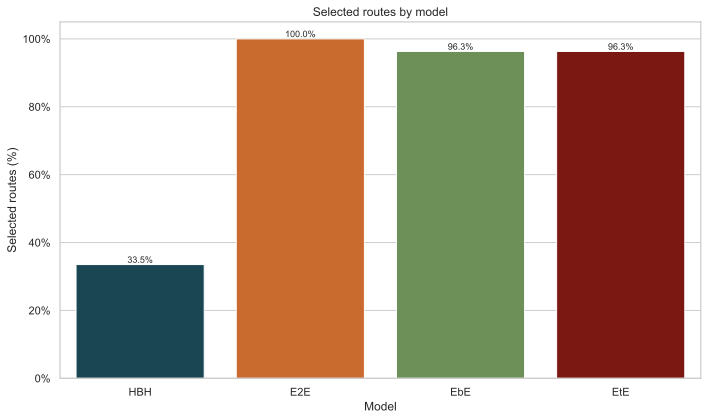

In [14]:
#| label: fig-gapminder
#| fig-cap: "Model 3 results"
#| fig-subcap:
#|   - "Minimum keys to guarantee at least 1 path per pair"
#|   - "Routes selected in the optimal solution"
#| layout-ncol: 2
#| column: page
#| echo: false
#| out-width: 100%

ax = plot_selected_keys_by_model(
    df_m3,
    normalize=True,
    title="Minimum keys by model",
)
ax.figure.tight_layout()
plt.show()

ax = plot_selected_routes_by_model(
    df_m3,
    normalize=True,
    title="Selected routes by model",
)
ax.figure.tight_layout()
plt.show()


## Model 4 - Maximize connectivity subject to a key budget

<table>
<tr>
<td style="width:50%; border:none; vertical-align:top;">

#### Notation
$$
\begin{aligned}
D &: \text{set of evaluated ordered source-destination pairs} \\
P_{sd} &: \text{set of candidate routes for pair } (s,d) \in D \\
P &= \bigcup_{(s,d) \in D} P_{sd} \\
K &: \text{global set of activatable key scopes} \\
K(p) &\subseteq K : \text{key scopes required by route } p \in P \\
B &: \text{maximum budget of active keys}
\end{aligned}
$$

$$
\begin{aligned}
x_{sd} &=
\begin{cases}
1 & \text{if pair } (s,d) \text{ is connected} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
y_p &=
\begin{cases}
1 & \text{if route } p \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\\[4pt]
z_k &=
\begin{cases}
1 & \text{if key scope } k \text{ is activated} \\
0 & \text{otherwise}
\end{cases}
\end{aligned}
$$

</td>
<td style="width:50%; border:none; vertical-align:top;">

#### Model
$$
\begin{aligned}
\max \quad & \sum_{(s,d) \in D} x_{sd} \\
\text{s.t.} \quad
& \sum_{k \in K} z_k \le B \\
& y_p \le x_{sd} \qquad \forall (s,d) \in D,\ \forall p \in P_{sd} \\
& x_{sd} \le \sum_{p \in P_{sd}} y_p \qquad \forall (s,d) \in D \\
& \sum_{k \in K(p)} z_k \ge |K(p)|\,y_p \qquad \forall p \in P \\
& x_{sd} \in \{0,1\} \qquad \forall (s,d) \in D \\
& y_p \in \{0,1\} \qquad \forall p \in P \\
& z_k \in \{0,1\} \qquad \forall k \in K
\end{aligned}
$$

</td>
</tr>
</table>

In the implementation, ties are broken by preferring fewer active keys and more active routes.


In [15]:
df_m4 = pd.DataFrame()
traces_m4 = {}

for sec_model in SERIES_COLORS.keys():
    print(f"Running for {sec_model.name}")

    sec_traces, sec_df = solve_m4_for_security_model(result, sec_model)
    traces_m4[sec_model.name] = dict(zip(sec_df["max_keys"], sec_traces))
    df_m4 = pd.concat([df_m4, sec_df], ignore_index=True)


Running for HOP_BY_HOP
Running for END_TO_END
Running for EDGE_BY_EDGE
Running for EDGE_TO_EDGE


<Axes: title={'center': 'Achieved connectivity vs active keys'}, xlabel='Active keys (%)', ylabel='Achieved connectivity (%)'>

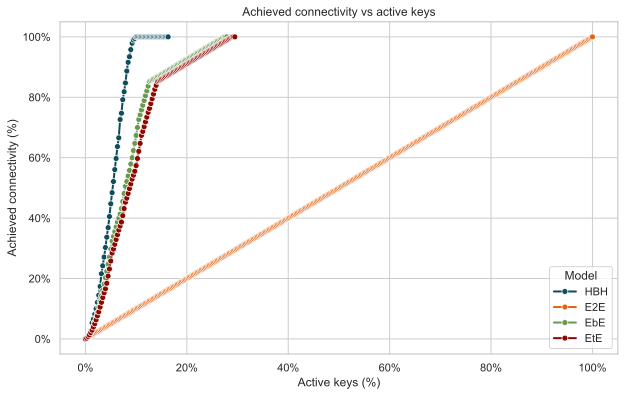

In [16]:
set_plot_theme()

plot_connectivity_vs_budget(df_m4)